# House Price Prediction EDA
## DSS5104 — CA 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "results"
DATA_PATH = "house_dataset.csv"

In [2]:
raw = pd.read_csv(DATA_PATH)

# Basic overview 
print("=== Shape ===")
print(raw.shape)        

print("\n=== Column dtypes ===")
print(raw.dtypes)

=== Shape ===
(9200, 18)

=== Column dtypes ===
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street            object
city              object
statezip          object
country           object
dtype: object


In [3]:
# Continue basic overview
print("\n=== First 5 rows ===")
print(raw.head())


=== First 5 rows ===
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated 

In [4]:
# Missing values 
print("\n=== Missing values per column ===")
print(raw.isnull().sum())

# Duplicates 
n_dup = raw.duplicated().sum()
print(f"\n=== Exact duplicate rows: {n_dup} out of {len(raw)} ===")


=== Missing values per column ===
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

=== Exact duplicate rows: 4598 out of 9200 ===



=== price descriptive stats ===
count    9.200000e+03
mean     5.519630e+05
std      5.638041e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

=== Rows with price <= 0: 98 ===
price
0.0      98
Name: count, dtype: int64


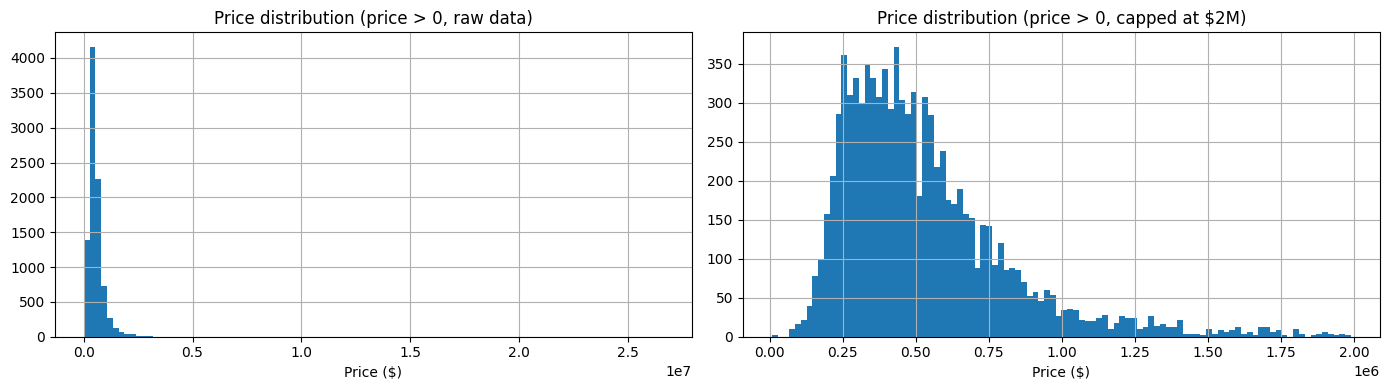

In [5]:
# Target variable: price 
print("\n=== price descriptive stats ===")
print(raw["price"].describe())

n_zero_neg = (raw["price"] <= 0).sum()
print(f"\n=== Rows with price <= 0: {n_zero_neg} ===")
print(raw[raw["price"] <= 0][["price"]].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize = (14, 4))
raw[raw["price"] > 0]["price"].hist(bins = 100, ax = axes[0])
axes[0].set_title("Price distribution (price > 0, raw data)")
axes[0].set_xlabel("Price ($)")

raw[raw["price"] > 0]["price"].apply(lambda x: x if x < 2_000_000 else None).dropna().hist(bins = 100, ax = axes[1])
axes[1].set_title("Price distribution (price > 0, capped at $2M)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.show()


=== Rows with sqft_living == 0: 0 ===

=== price_per_sqft descriptive stats ===
count     9200.000000
mean       265.893639
std        357.493290
min          0.000000
25%        180.819021
50%        243.805310
75%        314.843619
max      22533.898305
dtype: float64


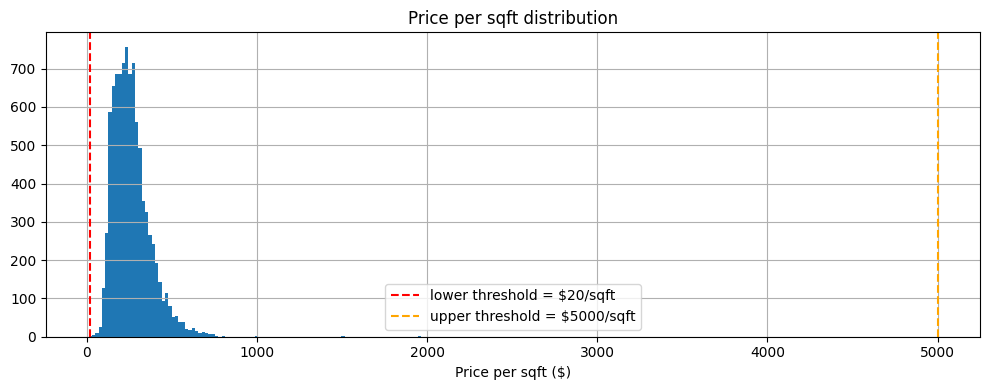

  Rows with price_per_sqft > $5000 : 4
  Rows with price_per_sqft < $20   : 100


In [6]:
# Outlier analysis: price per sqft 
# sqft_living of 0 would cause division by zero, check first
print(f"\n=== Rows with sqft_living == 0: {(raw['sqft_living'] == 0).sum()} ===")

price_per_sqft = raw["price"] / raw["sqft_living"].replace(0, 1)
print("\n=== price_per_sqft descriptive stats ===")
print(price_per_sqft.describe())

fig, ax = plt.subplots(figsize = (10, 4))
price_per_sqft[(price_per_sqft > 0) & (price_per_sqft < 2000)].hist(bins = 100, ax = ax)

ax.axvline(20,   color = "red",   linestyle = "--", label = "lower threshold = $20/sqft")
ax.axvline(5000, color = "orange", linestyle = "--", label = "upper threshold = $5000/sqft")

ax.set_title("Price per sqft distribution")
ax.set_xlabel("Price per sqft ($)")
ax.legend()
plt.tight_layout()
plt.show()

n_high = (price_per_sqft > 5000).sum()
n_low  = (price_per_sqft < 20).sum()
print(f"  Rows with price_per_sqft > $5000 : {n_high}")
print(f"  Rows with price_per_sqft < $20   : {n_low}")

In [7]:
# Zero-bedroom AND zero-bathroom rows
zero_rooms = raw[(raw["bedrooms"] == 0) & (raw["bathrooms"] == 0)]
print(f"\n=== Rows with bedrooms = 0 AND bathrooms = 0: {len(zero_rooms)} ===\n")
print(zero_rooms[["price", "sqft_living", "bedrooms", "bathrooms", "condition"]].head(10))
# These are data entry errors (a liveable property always has at least one room).


=== Rows with bedrooms = 0 AND bathrooms = 0: 4 ===

          price  sqft_living  bedrooms  bathrooms  condition
2365  1095000.0         3064       0.0        0.0          3
3209  1295648.0         4810       0.0        0.0          3
6965  1095000.0         3064       0.0        0.0          3
7809  1295648.0         4810       0.0        0.0          3


In [8]:
# Columns to drop
print("\n=== Sample values of low-utility columns ===")
print(raw[["street", "statezip", "country"]].head(10))
print(f"\n  Unique streets : {raw['street'].nunique()} out of {len(raw)} rows")
print(f"\n  Unique statezip : {raw['statezip'].nunique()} out of {len(raw)} rows")
print(f"\n  Unique countries: {raw['country'].nunique()} — value: {raw['country'].unique()}")
# 'street' is nearly unique per row (no predictive power once location encodings exist)
# 'statezip' is superseded by the extracted 'zipcode'
# 'country' has only one value — no information content


=== Sample values of low-utility columns ===
                     street  statezip country
0      18810 Densmore Ave N  WA 98133     USA
1           709 W Blaine St  WA 98119     USA
2  26206-26214 143rd Ave SE  WA 98042     USA
3           857 170th Pl NE  WA 98008     USA
4         9105 170th Ave NE  WA 98052     USA
5            522 NE 88th St  WA 98115     USA
6         2616 174th Ave NE  WA 98052     USA
7         23762 SE 253rd Pl  WA 98038     USA
8   46611-46625 SE 129th St  WA 98045     USA
9          6811 55th Ave NE  WA 98115     USA

  Unique streets : 4525 out of 9200 rows

  Unique statezip : 77 out of 9200 rows

  Unique countries: 1 — value: ['USA']



=== City value counts (top 10) ===
city
Seattle        3146
Renton          586
Bellevue        572
Redmond         470
Issaquah        374
Kirkland        374
Kent            370
Auburn          352
Sammamish       350
Federal Way     296
Name: count, dtype: int64

  Cities with fewer than 10 listings: 7 out of 44
  Rare cities:
city
Yarrow Point           8
Skykomish              6
Preston                4
Milton                 4
Inglewood-Finn Hill    2
Snoqualmie Pass        2
Beaux Arts Village     2
Name: count, dtype: int64


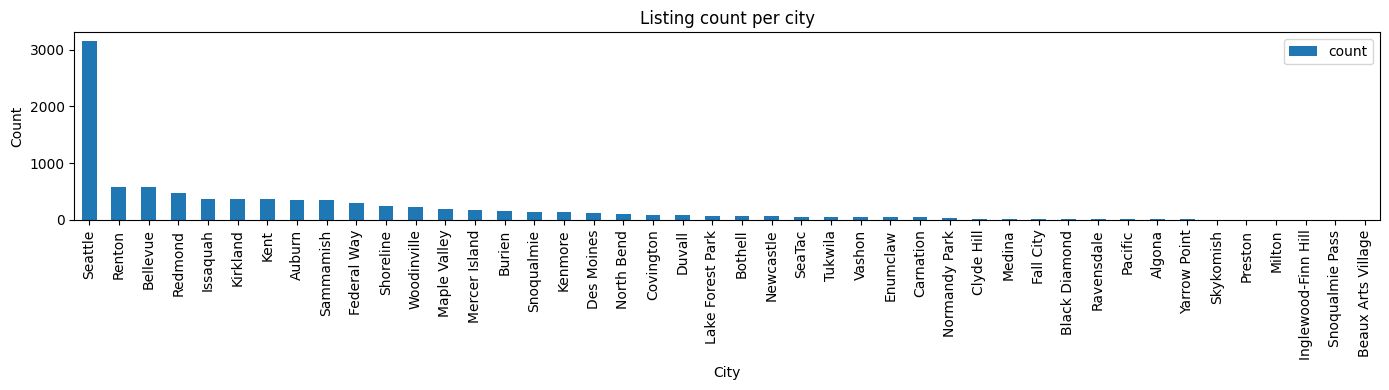

In [9]:
# City distribution: rare-city threshold
city_counts = raw["city"].value_counts()
print("\n=== City value counts (top 10) ===")
print(city_counts.head(10))

n_rare = (city_counts < 10).sum()
print(f"\n  Cities with fewer than 10 listings: {n_rare} out of {city_counts.shape[0]}")
print("  Rare cities:")
print(city_counts[city_counts < 10])
# With < 10 samples a city cannot be reliably split into train + test
# in a stratified split, so they are grouped as 'Other'.

fig, ax = plt.subplots(figsize = (14, 4))
city_counts.plot.bar(ax = ax)

ax.set_title("Listing count per city")
ax.set_xlabel("City")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()